In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
def exponential(t, amp, c, lifetime):
    return amp * np.exp(-t/lifetime) + c

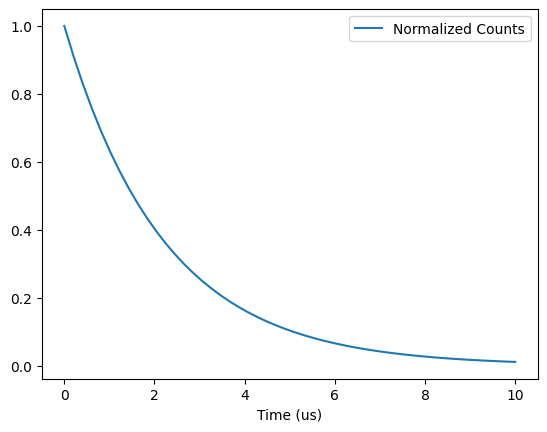

In [3]:
t = np.linspace(0,10,50)
plt.plot(t,exponential(t, 1, 0, 2.2),label='Normalized Counts')
plt.xlabel('Time (us)')
plt.legend()

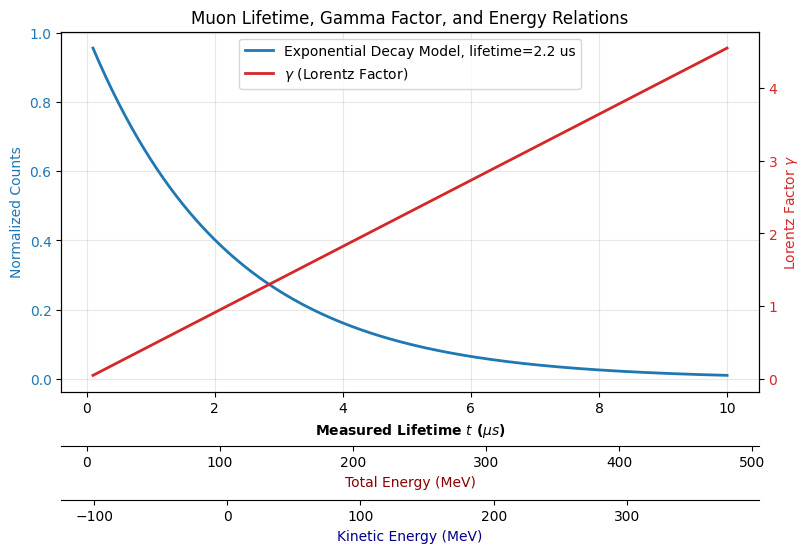

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Setup data
t = np.linspace(0.1, 10, 200)

tau_rest = 2.197      # muon rest lifetime (us)
m_mu = 105.66         # MeV/c^2

# Weighted / normalized counts
def exponential(x):
    return np.exp(-x / tau_rest)

# Lorentz gamma factor
gamma = t / tau_rest

# Create figure
fig, ax1 = plt.subplots(figsize=(9, 6))
plt.subplots_adjust(bottom=0.28)

# -----------------------------
# LEFT Y-AXIS : Weighted Counts
# -----------------------------
line1 = ax1.plot(
    t,
    exponential(t),
    color='tab:blue',
    linewidth=2,
    label='Exponential Decay Model, lifetime=2.2 us'
)

ax1.set_xlabel('Measured Lifetime $t$ ($\\mu s$)', fontweight='bold')
ax1.set_ylabel('Normalized Counts', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, alpha=0.3)

# -----------------------------
# RIGHT Y-AXIS : Gamma Factor
# -----------------------------
ax2 = ax1.twinx()

line2 = ax2.plot(
    t,
    gamma,
    color='tab:red',
    linewidth=2,
    label=r'$\gamma$ (Lorentz Factor)'
)

ax2.set_ylabel(r'Lorentz Factor $\gamma$', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# -----------------------------
# TOTAL ENERGY AXIS
# -----------------------------
def t_to_te(x):
    return (x / tau_rest) * m_mu

def te_to_t(x):
    return (x / m_mu) * tau_rest

ax_te = ax1.secondary_xaxis(
    -0.15,
    functions=(t_to_te, te_to_t)
)

ax_te.set_xlabel('Total Energy (MeV)', color='darkred')

# -----------------------------
# KINETIC ENERGY AXIS
# -----------------------------
def t_to_ke(x):
    return ((x / tau_rest) - 1) * m_mu

def ke_to_t(x):
    return ((x / m_mu) + 1) * tau_rest

ax_ke = ax1.secondary_xaxis(
    -0.30,
    functions=(t_to_ke, ke_to_t)
)

ax_ke.set_xlabel('Kinetic Energy (MeV)', color='darkblue')

# -----------------------------
# Combined Legend
# -----------------------------
lines = line1 + line2
labels = [l.get_label() for l in lines]

ax1.legend(lines, labels, loc='upper center')

plt.title('Muon Lifetime, Gamma Factor, and Energy Relations')
plt.show()

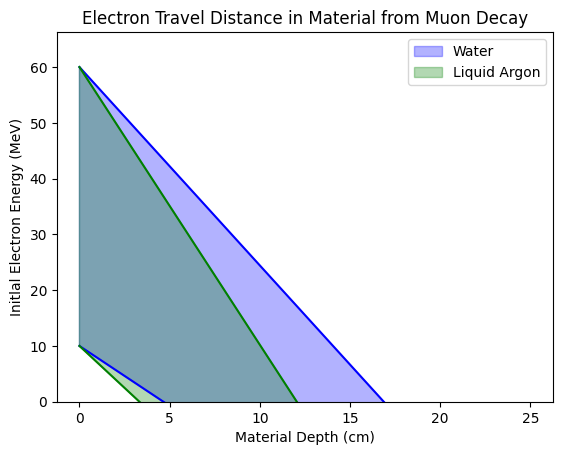

In [6]:
import numpy as np
import matplotlib.pyplot as plt

e_stopping = [2.149, 3.556]  # MeV cm^2/g
DEP = [2.992, 6.087]         # g/cm^2 (not used in this snippet yet)
e_energy = [10, 60]          # MeV
material_density = 1         # g/cm^3

distance = np.linspace(0, 25, 50)

# Compute energy curves
E1 = e_energy[0] - (e_stopping[0] * material_density) * distance
E2 = e_energy[1] - (e_stopping[1] * material_density) * distance

plt.plot(distance, E1, c='b')
plt.plot(distance, E2, c='b')

# Shade region between curves
plt.fill_between(distance, E1, E2, alpha=0.3,label='Water', color='b')

material_density = 1.4

E1 = e_energy[0] - (e_stopping[0] * material_density) * distance
E2 = e_energy[1] - (e_stopping[1] * material_density) * distance

plt.plot(distance, E1, c='g')
plt.plot(distance, E2, c='g')

# Shade region between curves
plt.fill_between(distance, E1, E2, alpha=0.3,label='Liquid Argon', color='g')

plt.xlabel('Material Depth (cm)')
plt.ylabel('Initlal Electron Energy (MeV)')
plt.ylim(bottom=0)
plt.legend()
plt.title('Electron Travel Distance in Material from Muon Decay')
plt.show()